In [1]:
import numpy as np

import os

from nbodykit.lab import *
from nbodykit import setup_logging, style

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import SymLogNorm

import scipy.integrate as integrate
from scipy import spatial

from matplotlib.patches import Circle

from astropy.cosmology import FlatLambdaCDM

In [2]:
from baryonification.baryonification.params import par
from baryonification.baryonification.cosmo import cosmo
from baryonification.baryonification.displ import displace
from baryonification.baryonification.halo_displ import displace_haloes

from miniramses.utils.py.miniramses import rd_info
from miniramses.utils.py.miniramses import Info

In [3]:
#initialise parameters

par = par()

if par.code.multicomp:
    comp = 'multicomp' #'multicomp' or 'singlecomp'
else:
    comp = 'singlecomp'

size = par.code.size #'big' or 'small'

par.files.transfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/CDM_PLANCK_tk.dat"
par.files.cosmofct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/cosmofct.dat"
par.files.displfct = "/home/jamesdr/usrp2024/baryonification/baryonification/files/displfct.dat"
par.files.halofile_format = "ramses"
par.files.partfile_format = "ramses"
if size == 'big':
    par.files.partfile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
    par.files.halofile_in = "/scratch/gpfs/rt3504/bigbox/output_00011"
elif size == 'small':
    par.files.halofile_in = "/home/jamesdr/scratch/smallbox/output_00011"
    par.files.partfile_in = "/home/jamesdr/scratch/smallbox/output_00011"
par.files.partfile_out = "/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size)
par.files.halofile_out = "/home/jamesdr/usrp2024/{}_{}/halofile_out.std".format(comp,size)

Found 134217728 particles


In [4]:
import re

# Extracting the path using regular expression
path = re.match(r'(.*/{}box/)'.format(size), par.files.partfile_in).group(1)

# Extracting the number as an integer
nout = int(re.match(r'.*/output_(\d+)', par.files.partfile_in).group(1))

i = rd_info(nout, path=path)
unit_l = i.unit_l
unit_d = i.unit_d #g/cm^3
unit_m = unit_d * (unit_l)**3.0
unit_m_in_Msol_per_h = unit_m / (1.989e33) * par.cosmo.h0
unit_l_in_Mpc_per_h = unit_l / (3.086e24) * par.cosmo.h0

In [5]:
from baryonification.baryonification.io import read_nbody_file

In [6]:
p_header, non_displaced_dm = read_nbody_file(par)

Found 134217728 particles


In [7]:
def read_displaced_particles(file):

    Lbox   = unit_l / (3.086e24) * par.cosmo.h0
    N_chunk = 1
    L_chunk = Lbox/N_chunk
    
    Om = i.omega_m
    z  = par.cosmo.z
    
    f = open(file, 'r')

    #header
    p_header_dt = np.dtype([('a','>d'),('Npart','>i'),('dim','>i'),('Ngas','>i'),('Ndm','>i'),('Nstar','>i'),('buffer','>i')])
    p_header = np.fromfile(f, dtype=p_header_dt, count=1, sep='')
    
    #gas
    p_gas_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                               ('vz', '>f4'),('rho','>f4'),('temp','>f4'),('hsmooth','>f4'),('metals','>f4'),('phi','>f4')])
    p_gas = np.fromfile(f, dtype=p_gas_dt, count=int(p_header['Ngas']), sep='')
    
    #dm
    p_dm_dt   = np.dtype([('mass','>f4'),("x",'>f4'),("y",'>f4'),("z",'>f4'),("vx",'>f4'),("vy",'>f4'),("vz",'>f4'),\
                                ("eps",'>f4'),("phi",'>f4')])
    p_dm = np.fromfile(f, dtype=p_dm_dt, count=int(p_header['Ndm']), sep='')
    
    #stars
    p_star_dt = np.dtype([('mass','>f4'),('x', '>f4'),('y', '>f4'),('z', '>f4'),('vx', '>f4'),('vy', '>f4'),\
                                 ('vz', '>f4'),('metals','>f4'),('tform','>f4'),('eps','>f4'),('phi','>f4')])
    p_star = np.fromfile(f, dtype=p_star_dt, count=int(p_header['Nstar']), sep='')

    #convert to Mpc/h
    p_gas['x']=Lbox*(p_gas['x']+0.5)
    p_gas['y']=Lbox*(p_gas['y']+0.5)
    p_gas['z']=Lbox*(p_gas['z']+0.5)
    p_dm['x']=Lbox*(p_dm['x']+0.5)
    p_dm['y']=Lbox*(p_dm['y']+0.5)
    p_dm['z']=Lbox*(p_dm['z']+0.5)
    p_star['x']=Lbox*(p_star['x']+0.5)
    p_star['y']=Lbox*(p_star['y']+0.5)
    p_star['z']=Lbox*(p_star['z']+0.5)

    #convert to Mstar/h
    print("Om = ", np.sum(p_gas['mass'])+np.sum(p_dm['mass'])+np.sum(p_star['mass']))
    p_gas['mass'] = p_gas['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_dm['mass'] = p_dm['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
    p_star['mass'] = p_star['mass'] * 2.776e11*(Om*(1.0+z)**3.0 + (1.0-Om))/(1.0+z)**3.0 *Lbox**3
        
    print('Reading tipsy-file done!')
    
    #split particles into chunks
    p_gas_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_gas = np.where((p_gas['x']>=x_min) & (p_gas['x']<x_max) & (p_gas['y']>=y_min) & (p_gas['y']<y_max) & (p_gas['z']>=z_min) & (p_gas['z']<z_max))
                p_gas_list += [p_gas[ID_gas]]
                
    #split particles into chunks
    p_dm_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_dm = np.where((p_dm['x']>=x_min) & (p_dm['x']<x_max) & (p_dm['y']>=y_min) & (p_dm['y']<y_max) & (p_dm['z']>=z_min) & (p_dm['z']<z_max))
                p_dm_list += [p_dm[ID_dm]]
                
    #split particles into chunks
    p_star_list   = []
    for x_min in np.linspace(0,Lbox-L_chunk,N_chunk):
        x_max = x_min + L_chunk
        if (x_max == Lbox):
            x_max = 1.00001*x_max
        for y_min in np.linspace(0,Lbox-L_chunk,N_chunk):
            y_max =y_min + L_chunk
            if (y_max == Lbox):
                    y_max = 1.00001*y_max
            for z_min in np.linspace(0,Lbox-L_chunk,N_chunk):
                z_max = z_min + L_chunk
                if (z_max == Lbox):
                        z_max = 1.00001*z_max
                ID_star = np.where((p_star['x']>=x_min) & (p_star['x']<x_max) & (p_star['y']>=y_min) & (p_star['y']<y_max) & (p_star['z']>=z_min) & (p_star['z']<z_max))
                p_star_list += [p_star[ID_star]]
    
    return p_header, p_gas_list, p_dm_list, p_star_list

In [8]:
p_displaced_header, displaced_gas, displaced_dm, displaced_stars = read_displaced_particles("/home/jamesdr/usrp2024/{}_{}/partfile_out.std".format(comp,size))

Om =  0.27524456
Reading tipsy-file done!


In [9]:
gas_tree = spatial.cKDTree(list(zip(displaced_gas[0]['x'],displaced_gas[0]['y'],displaced_gas[0]['z'])), leafsize=100, boxsize=unit_l_in_Mpc_per_h)
dm_tree = spatial.cKDTree(list(zip(non_displaced_dm[0]['x'],non_displaced_dm[0]['y'],non_displaced_dm[0]['z'])), leafsize=100, boxsize=unit_l_in_Mpc_per_h)

In [10]:
from baryonification.baryonification.io import read_halo_file
haloes = read_halo_file(par)

Found 132551 clumps
Converting r200b, M200b, and c200b to r200c, M200c, and c200c


/home/jamesdr/.conda/envs/usrp2024/lib/python3.8/site-packages/scipy/optimize/minpack.py:175: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


Done!


In [11]:
#Now we take the largest halo, compute the SZ signal, turn it to a function of distance from halo center, and plot it

N = 20

sorted_halo_index = np.argsort(haloes[0]['Mvir'])

top = sorted_halo_index[-N :]

In [12]:
Om0 = 0.308
Ob0 = 0.0486
baryon_correction_factor = Ob0/Om0
cosmo = FlatLambdaCDM(H0=67.74, Om0 = Om0, Ob0 = Ob0, Tcmb0 = 2.7255, Neff = 3.046) #Neutrino mass is 0 by default
c_km = 3e5 #km/s
sigmat = 6.98426e-74 * (cosmo.h)**2 #(Mpc/h)^2
m_p = 1.67262192e-27/1.989e+30 * cosmo.h #Msol/h
r = 3.0 #This is in Rvir. We find all points within this distance
bins = int(r*100.0)
Lbox = unit_l_in_Mpc_per_h

electrons_per_particle = displaced_gas[0]['mass'][0] / m_p
Mpc_per_pixel = unit_l_in_Mpc_per_h/bins

In [13]:
gas_weights = electrons_per_particle * sigmat / c_km * displaced_gas[0]['vz'] / ((Mpc_per_pixel)**2.0)

In [14]:
gas_profile = np.zeros((bins, bins, N))

for i in range(N):
    #We consider one halo at a time
    idhost = top[i]
    ID = gas_tree.query_ball_point((haloes[0]['x'][idhost],haloes[0]['y'][idhost],haloes[0]['z'][idhost]), r*haloes[0]['rvir'][idhost]) 
    norm_x = displaced_gas[0]['x'][ID]-haloes[0]['x'][idhost]
    norm_y = displaced_gas[0]['y'][ID]-haloes[0]['y'][idhost]
    #This for loop imposes the periodic boundary conditions
    #Basically, for every particle outside the radius because it's on the other side of the box...
    #...this for loop shifts it so it's back to being by the central halo
    for j in range(len(norm_x)):
        if norm_x[j] < -Lbox/2.0:
            norm_x[j] += Lbox
        elif norm_x[j] > Lbox/2.0:
            norm_x[j] -= Lbox
    for j in range(len(norm_y)):
        if norm_y[j] < -Lbox/2.0:
            norm_y[j] += Lbox
        elif norm_y[j] > Lbox/2.0:
            norm_y[j] -= Lbox

    norm_x = norm_x/haloes[0]['rvir'][idhost]
    norm_y = norm_y/haloes[0]['rvir'][idhost]
    #We develop a histogram
    #weights[iphalo==itest]*haloes[0]['vz'][itest]
    gas_hist, gas_xedges, gas_yedges = np.histogram2d(norm_x, norm_y,bins=bins,weights=gas_weights[ID]*haloes[0]['vz'][idhost])
    gas_hist=gas_hist.T

    gas_profile[:,:,i] += gas_hist

In [15]:
dm_electrons_per_particle = non_displaced_dm[0]['mass'][0] / m_p

In [16]:
dm_weights = baryon_correction_factor * dm_electrons_per_particle * sigmat / c_km * displaced_dm[0]['vz'] / ((Mpc_per_pixel)**2.0)

In [17]:
dm_profile = np.zeros((bins, bins, N))

for i in range(N):
    #We consider one halo at a time
    idhost = top[i]
    ID = dm_tree.query_ball_point((haloes[0]['x'][idhost],haloes[0]['y'][idhost],haloes[0]['z'][idhost]), r*haloes[0]['rvir'][idhost]) 
    norm_x = displaced_dm[0]['x'][ID]-haloes[0]['x'][idhost]
    norm_y = displaced_dm[0]['y'][ID]-haloes[0]['y'][idhost]
    #This for loop imposes the periodic boundary conditions
    #Basically, for every particle outside the radius because it's on the other side of the box...
    #...this for loop shifts it so it's back to being by the central halo
    for j in range(len(norm_x)):
        if norm_x[j] < -Lbox/2.0:
            norm_x[j] += Lbox
        elif norm_x[j] > Lbox/2.0:
            norm_x[j] -= Lbox
    for j in range(len(norm_y)):
        if norm_y[j] < -Lbox/2.0:
            norm_y[j] += Lbox
        elif norm_y[j] > Lbox/2.0:
            norm_y[j] -= Lbox

    norm_x = norm_x/haloes[0]['rvir'][idhost]
    norm_y = norm_y/haloes[0]['rvir'][idhost]
    #We develop a histogram
    #weights[iphalo==itest]*haloes[0]['vz'][itest]
    dm_hist, dm_xedges, dm_yedges = np.histogram2d(norm_x, norm_y,bins=bins,weights=dm_weights[ID]*haloes[0]['vz'][idhost])
    dm_hist=dm_hist.T
    
    dm_profile[:,:,i] += dm_hist

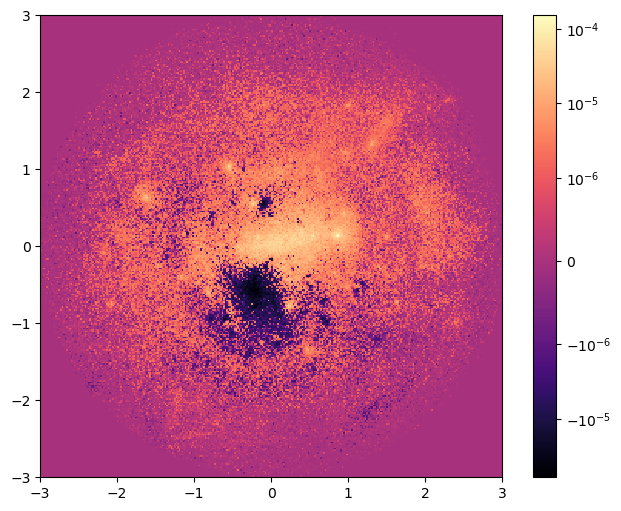

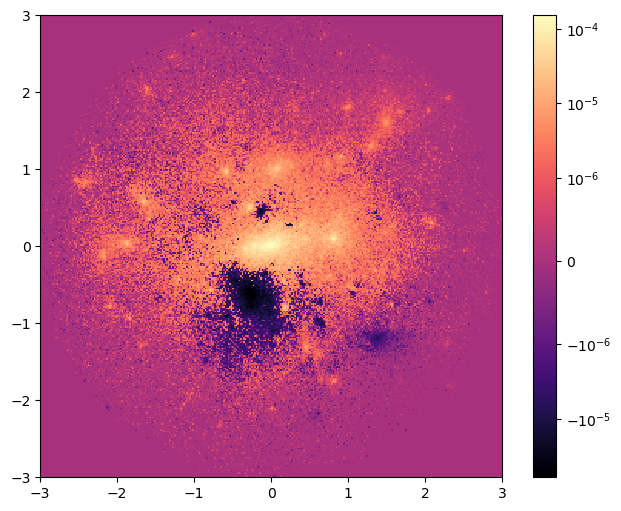

In [18]:
total_gas_profile = np.sum(gas_profile,axis=2)
total_dm_profile = np.sum(dm_profile,axis=2)

xedges = np.linspace(-3, 3, bins+1)
yedges = np.linspace(-3, 3, bins+1)

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(total_gas_profile), vmax=np.max(total_gas_profile))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(total_gas_profile, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

plt.show()

norm = SymLogNorm(linthresh=1.0e-6, linscale=1.0, vmin=np.min(total_gas_profile), vmax=np.max(total_gas_profile))

# Plotting in log-log scale
plt.figure(figsize=(8, 6))
plt.imshow(total_dm_profile, interpolation='nearest', origin='lower', extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]], norm=norm, cmap='magma')

# Add colorbar
plt.colorbar()

plt.show()

In [19]:
x_center = (xedges[0] + xedges[-1]) / 2
y_center = (yedges[0] + yedges[-1]) / 2

In [20]:
x_bins, y_bins = np.meshgrid(xedges[:-1], yedges[:-1])

In [21]:
distances = np.sqrt((x_bins - x_center) ** 2 + (y_bins - y_center) ** 2)

In [22]:
flat_distances = distances.flatten()
flat_gas_hist = total_gas_profile.flatten()
flat_dm_hist = total_dm_profile.flatten()

In [23]:
distance_bins = np.linspace(0, np.max(flat_distances)/np.sqrt(2), num=30)
digitized = np.digitize(flat_distances, distance_bins)

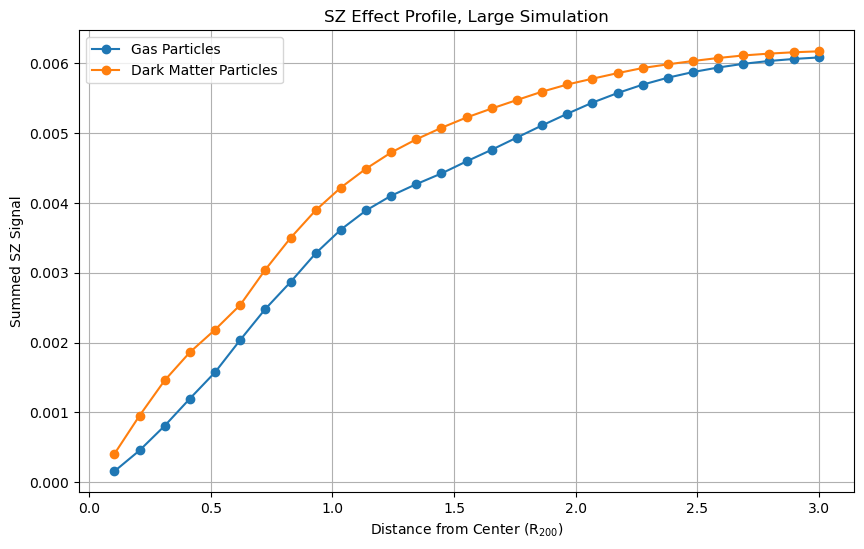

In [24]:
gas_values = np.array([np.sum(np.abs(flat_gas_hist[digitized <= i])) for i in range(1, len(distance_bins))])/N
dm_values = np.array([np.sum(np.abs(flat_dm_hist[digitized <= i])) for i in range(1, len(distance_bins))])/N
plt.figure(figsize=(10, 6))
plt.plot(distance_bins[1:], gas_values, marker='o',label='Gas Particles')
plt.plot(distance_bins[1:], dm_values, marker='o',label='Dark Matter Particles')
plt.xlabel(r'Distance from Center (R$_{200}$)')
plt.ylabel('Summed SZ Signal')
if size=='small':
    plt.title("SZ Effect Profile, Small Simulation")
if size=='big':
    plt.title("SZ Effect Profile, Large Simulation")
# plt.ylim(0,0.009)
plt.grid()
plt.legend()

plt.savefig(os.path.join('{}_{}'.format(comp, size), 'SZProfile.pdf'), bbox_inches='tight')

plt.show()